In [72]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
from src.training import load_dataset

dataset_easy = load_dataset("datasets/E4F_1-1.data")
dataset_medium = load_dataset("datasets/E4F_2-8.data")
dataset_hard = load_dataset("datasets/E4F_9-64.data")

# Decoder-only model

In [6]:
from src.models.decoder_model import DecoderModel

# Parámetros del modelo
input_dim = 18     # features de las acciones
num_heads = 4
head_dim = 32
num_layers = 2
dropout = 0.1

# Crear modelo
model = DecoderModel(
    input_dim=input_dim,
    num_heads=num_heads,
    head_dim=head_dim,
    num_layers=num_layers,
    dropout_rate=dropout
)

In [14]:
from src.training import curriculum_learning

epochs = [0, 100]
train_set = [dataset_easy, dataset_medium]
train_size = 2500
test_sets = [dataset_easy, dataset_medium, dataset_hard]
test_size = 1000
batch_size = 32
learning_rate = 1e-4
patience = 10
seed = 42

stats = curriculum_learning(model, epochs, train_set, train_size, test_sets, test_size, batch_size, learning_rate, patience, seed)

Epoch 1/100 - Train Loss: 2.6511, Train Accuracy: 35.48% - Val Loss: 2.1185, Val Accuracy: 41.00%
    Test Set: datasets/E4F_1-1.data - Val Loss: 1.3368, Val Accuracy: 73.40%
    Test Set: datasets/E4F_2-8.data - Val Loss: 2.9002, Val Accuracy: 8.60%
    Test Set: datasets/E4F_9-64.data - Val Loss: 7.0219, Val Accuracy: 0.13%
    Average - Val Loss: 3.7529, Val Accuracy: 27.38%
Epoch 2/100 - Train Loss: 2.0280, Train Accuracy: 41.52% - Val Loss: 2.0136, Val Accuracy: 42.10%
    Test Set: datasets/E4F_1-1.data - Val Loss: 1.2013, Val Accuracy: 77.70%
    Test Set: datasets/E4F_2-8.data - Val Loss: 2.8259, Val Accuracy: 6.50%
    Test Set: datasets/E4F_9-64.data - Val Loss: 7.6064, Val Accuracy: 0.00%
    Average - Val Loss: 3.8778, Val Accuracy: 28.07%
Epoch 3/100 - Train Loss: 1.9562, Train Accuracy: 42.80% - Val Loss: 1.9770, Val Accuracy: 42.20%
    Test Set: datasets/E4F_1-1.data - Val Loss: 1.1519, Val Accuracy: 76.40%
    Test Set: datasets/E4F_2-8.data - Val Loss: 2.8021, Val Acc

KeyboardInterrupt: 

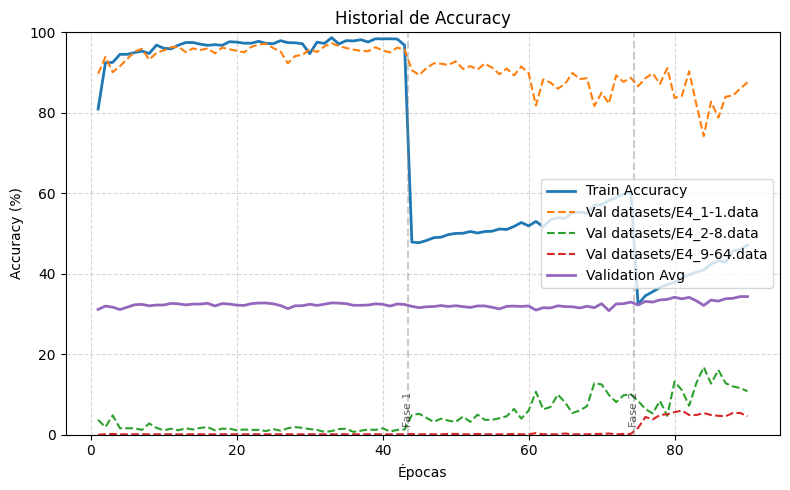

In [21]:
stats.plot()

In [ ]:
from src.training import *

save_model(model, "decoder_acl.pth")

# Encoder-decoder

In [75]:
len(dataset_easy[0][1][0])

7

In [56]:
from src.models.transformer import Transformer

# Parámetros del modelo
src_dim = 3      # input encoder
tgt_dim = 18     # input decoder
num_heads = 4
head_dim = 32
num_layers = 2
dropout = 0.1

# Crear modelo
model = Transformer(
    src_dim = src_dim,
    tgt_dim = tgt_dim,
    num_heads=num_heads,
    head_dim=head_dim,
    num_layers=num_layers,
    dropout_rate=dropout
)

In [54]:
from importlib import reload
import src.training
reload(src.training)

<module 'src.training' from '/home/oscar/CLP-Framework/src/training.py'>

In [71]:
import gc
gc.collect()

5405

In [70]:
from src.training import curriculum_learning

epochs = [0, 100]
train_set = [dataset_easy, dataset_medium]
train_size = 100
test_sets = [dataset_easy, dataset_medium, dataset_hard]
test_size = 50
batch_size = 1
learning_rate = 1e-4
patience = 10
seed = 42

stats = curriculum_learning(model, epochs, train_set, train_size, test_sets, test_size, batch_size, learning_rate, patience, seed)

Epoch 1/100 - Train Loss: 1.6683, Train Accuracy: 50.00% - Val Loss: 2.2651, Val Accuracy: 40.00%
    Test Set: datasets/E4F_1-1.data - Val Loss: 1.1945, Val Accuracy: 72.00%
    Test Set: datasets/E4F_2-8.data - Val Loss: 3.3357, Val Accuracy: 8.00%
    Test Set: datasets/E4F_9-64.data - Val Loss: 7.3445, Val Accuracy: 0.00%
    Average - Val Loss: 3.9582, Val Accuracy: 26.67%


KeyboardInterrupt: 